# Modeling P-KNN - Hugo Fiévet

## Table of Contents

1. [Objective](#1-objective)
2. [Baseline Model](#2-baseline-model)
3. [Hyperparameter Tuning](#3-hyperparameter-tuning)
4. [Final Evaluation](#4-final-evaluation)
5. [Model Limits](#5-model-limits)

## 1. Objective

Établir une performance de référence du modèle avec ses paramètres par défaut avant optimisation des hyperparamètres.

## 2. Baseline Model



In [1]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, cross_validate,GridSearchCV,StratifiedKFold
from sklearn.metrics import  accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

RANDOM_STATE = 42

knn =  KNeighborsClassifier(n_jobs=-1)

xtrain_P = pd.read_csv("../data/selected/xtrain_P.csv")
ytrain = pd.read_csv("../data/processed/ytrain.csv").squeeze("columns")

StratifiedKfold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = cross_validate(estimator=knn,X=xtrain_P,y=ytrain,scoring="f1_macro",return_train_score=True,cv=StratifiedKfold_cv)
pd.DataFrame(cv_results)


,fit_time,score_time,test_score,train_score
0,0.042743,0.139694,0.688097,0.785756
1,0.022742,0.133923,0.674450,0.777920
2,0.053555,0.229011,0.691558,0.782307
3,0.070041,0.403150,0.668884,0.777958
4,0.058410,0.250277,0.679427,0.781664


In [2]:
print("Mean train score : ",cv_results["train_score"].mean())
print("Mean validation score",cv_results["test_score"].mean())

Mean train score :  0.7811212015027229
Mean validation score 0.6804830529032239


Le KNN avec ses paramètres par défaut obtient un F1-macro moyen d’environ **0,680** en validation croisée, contre **0,781** sur l’entraînement.

L’écart entraînement–validation est d’environ **0,101**, ce qui indique un surapprentissage modéré.

Cette baseline sert de référence pour mesurer l’effet du tuning des hyperparamètres du KNN.

## 3. Hyperparameter Tuning

In [3]:
settings_grid = {
    #['algorithm', 'leaf_size', 'metric', 'metric_params', 'n_jobs', 'n_neighbors', 'p', 'weights']
   "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "p":[1,2]
}

grid_search = GridSearchCV(estimator=knn,param_grid=settings_grid,scoring="f1_macro",cv=StratifiedKfold_cv,return_train_score=True)

grid_search.fit(
    X=xtrain_P,
    y=ytrain
)


,estimator,KNeighborsCla...ier(n_jobs=-1)
,param_grid,"{'n_neighbors': [3, 5, ...], 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_neighbors,15


In [4]:
best_index = grid_search.best_index_

print("Best parameters:", grid_search.best_params_)

print("Best validation F1:", grid_search.best_score_)
print(
    "Mean train F1:",
    grid_search.cv_results_["mean_train_score"][best_index]
)
print(
    "Std validation F1:",
    grid_search.cv_results_["std_test_score"][best_index]
)

Best parameters: {'n_neighbors': 15, 'p': 1, 'weights': 'distance'}
Best validation F1: 0.6945004135957963
Mean train F1: 1.0
Std validation F1: 0.005104621804340693


L’optimisation sélectionne `n_neighbors=15`, `p=1` et `weights="distance"`.

Le F1-macro moyen de validation passe d’environ **0,680 à 0,695**, soit une amélioration d’environ **0,014**. En revanche, le F1-macro moyen d’entraînement atteint **1,000**.

L’écart entraînement–validation augmente donc d’environ **0,101 à 0,306**. Le tuning améliore légèrement la validation, mais rend le modèle beaucoup plus sujet au surapprentissage.

Le paramètre `p=1` correspond à la distance de Manhattan. Avec `weights="distance"`, les voisins les plus proches ont davantage d’influence, ce qui peut favoriser une mémorisation très forte des données d’entraînement.

L’écart-type du F1-macro de validation est d’environ **0,005**, ce qui montre néanmoins une bonne stabilité entre les folds.

## 4. Final Evaluation



In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
X_test_P = pd.read_csv("../data/selected/xtest_P.csv")
y_test = pd.read_csv("../data/processed/ytest.csv").squeeze("columns")

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X=X_test_P)

class_report = classification_report(y_test, y_pred)
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy :",accuracy )
print("Precision macro :",precision )
print("Recall macro :",recall )
print("F1 macro :", f1)

Accuracy : 0.7407213800313643
Precision macro : 0.7055293794274565
Recall macro : 0.7078546508972066
F1 macro : 0.7042103815069108


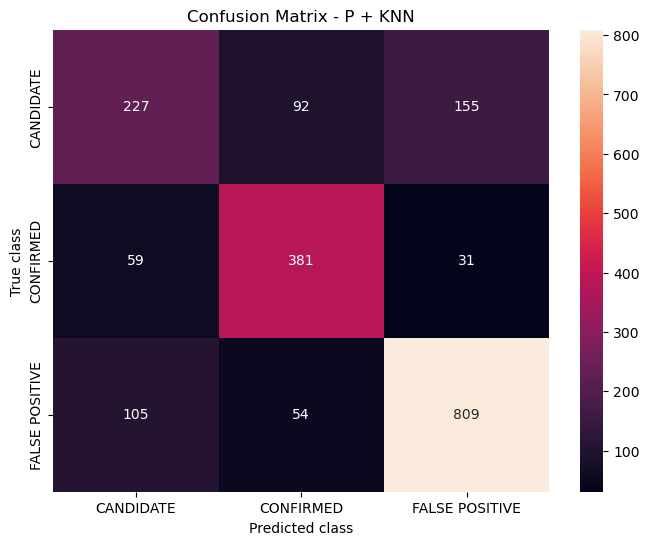

In [6]:
labels = ["CANDIDATE", "CONFIRMED", "FALSE POSITIVE"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix - P + KNN")

plt.show()

Sur le jeu de test indépendant, ce KNN obtient :

- **Accuracy : 0,7407**
- **Precision macro : 0,7055**
- **Recall macro : 0,7079**
- **F1 macro : 0,7042**

Le F1-macro de test est légèrement supérieur au score moyen de validation croisée (**0,6945**), ce qui reste cohérent avec la variabilité attendue entre validation et test.

Le score d’entraînement égal à **1,000** montre cependant un surapprentissage très marqué. La performance sur le test reste correcte, mais le modèle optimisé est moins équilibré que ce que laisserait penser le seul gain de F1 en validation.

## 5. Model Limits

Comme observé avec les autres modèles, la difficulté concernant CANDIDATE peut être liée à l’ambiguïté intrinsèque de cette classe. Un candidat KOI n’est justement pas encore clairement confirmé ou rejeté, ce qui peut expliquer qu’il partage certaines caractéristiques avec les deux autres catégories.